In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/customer churn data.csv")

print(df.head())
print(df.shape)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [2]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

/tmp/ipykernel_2800/3692201336.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [4]:
df.drop("customerID", axis=1, inplace=True)

In [5]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

In [6]:
df = pd.get_dummies(df, drop_first=True)

In [7]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [11]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0 1 0 0 0 1 0 0 0 0]


In [12]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8069552874378992


In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[925 110]
 [162 212]]


In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [15]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.8415846443979436


In [16]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance["Abs_Coefficient"] = abs(importance["Coefficient"])

importance = importance.sort_values(
    "Abs_Coefficient",
    ascending=False
)

print(importance.head(15))

                                 Feature  Coefficient  Abs_Coefficient
1                                 tenure    -1.219639         1.219639
2                         MonthlyCharges    -0.921369         0.921369
10           InternetService_Fiber optic     0.778760         0.778760
25                     Contract_Two year    -0.588975         0.588975
3                           TotalCharges     0.497246         0.497246
24                     Contract_One year    -0.286473         0.286473
23                   StreamingMovies_Yes     0.258653         0.258653
21                       StreamingTV_Yes     0.258042         0.258042
9                      MultipleLines_Yes     0.216356         0.216356
26                  PaperlessBilling_Yes     0.181833         0.181833
28        PaymentMethod_Electronic check     0.181456         0.181456
13                    OnlineSecurity_Yes    -0.123430         0.123430
6                         Dependents_Yes    -0.104249         0.104249
19    

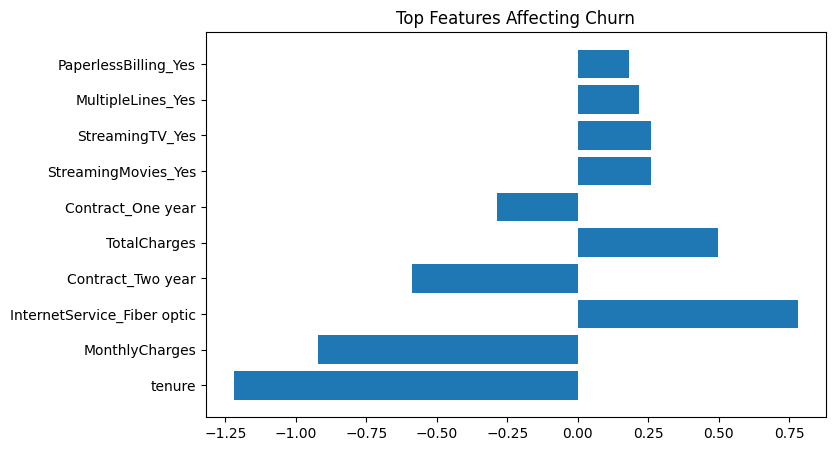

In [17]:
import matplotlib.pyplot as plt

top = importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top["Feature"], top["Coefficient"])
plt.title("Top Features Affecting Churn")
plt.show()

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

Accuracy: 0.7920511000709723
ROC-AUC: 0.8258518690743755


In [19]:
results = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest"],
    "Accuracy":[
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,rf_pred)
    ],
    "ROC_AUC":[
        roc_auc_score(y_test,y_prob),
        roc_auc_score(y_test,rf_prob)
    ]
})

print(results)

                 Model  Accuracy   ROC_AUC
0  Logistic Regression  0.806955  0.841585
1        Random Forest  0.792051  0.825852


In [20]:
importance_rf = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_rf = importance_rf.sort_values(
    "Importance",
    ascending=False
)

print(importance_rf.head(15))

                           Feature  Importance
3                     TotalCharges    0.194123
1                           tenure    0.171364
2                   MonthlyCharges    0.167562
10     InternetService_Fiber optic    0.038864
28  PaymentMethod_Electronic check    0.038285
25               Contract_Two year    0.031477
4                      gender_Male    0.028519
13              OnlineSecurity_Yes    0.027796
26            PaperlessBilling_Yes    0.025725
5                      Partner_Yes    0.023285
24               Contract_One year    0.022860
19                 TechSupport_Yes    0.022381
15                OnlineBackup_Yes    0.021352
0                    SeniorCitizen    0.020622
9                MultipleLines_Yes    0.019867


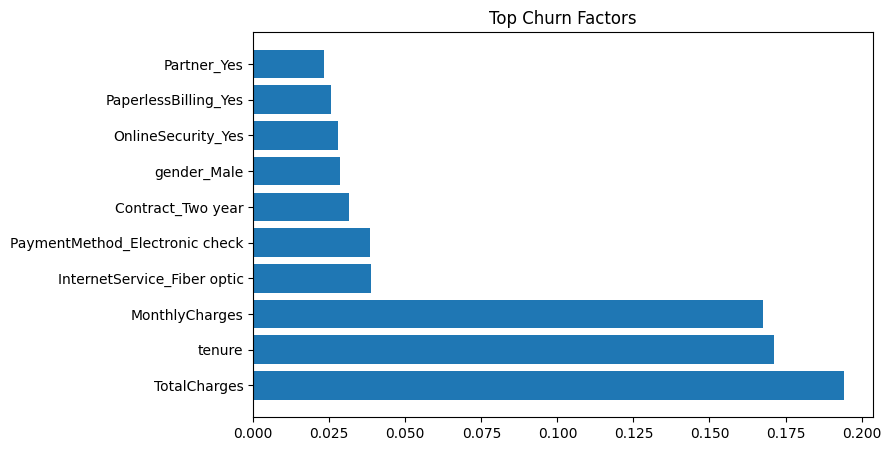

In [21]:
import matplotlib.pyplot as plt

top = importance_rf.head(10)

plt.figure(figsize=(8,5))
plt.barh(top["Feature"], top["Importance"])
plt.title("Top Churn Factors")
plt.show()

In [22]:
import joblib

joblib.dump(rf, "customer_churn_model.pkl")

['customer_churn_model.pkl']

In [23]:
sample = X.iloc[[0]]

prediction = rf.predict(sample)

print(prediction)

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [25]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_prob))

Accuracy: 0.7977288857345636
ROC-AUC: 0.8436164716215866


In [26]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

print(results)

                 Model  Accuracy   ROC_AUC
0  Logistic Regression  0.806955  0.841585
1        Random Forest  0.792051  0.825852
2              XGBoost  0.797729  0.843616


In [27]:
importance_xgb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance_xgb = importance_xgb.sort_values(
    by="Importance",
    ascending=False
)

print(importance_xgb.head(15))

                           Feature  Importance
10     InternetService_Fiber optic    0.256286
24               Contract_One year    0.223480
25               Contract_Two year    0.191546
11              InternetService_No    0.056984
23             StreamingMovies_Yes    0.040152
28  PaymentMethod_Electronic check    0.036493
1                           tenure    0.035060
13              OnlineSecurity_Yes    0.020850
26            PaperlessBilling_Yes    0.016342
19                 TechSupport_Yes    0.015139
9                MultipleLines_Yes    0.013702
21                 StreamingTV_Yes    0.010886
3                     TotalCharges    0.010633
17            DeviceProtection_Yes    0.008823
6                   Dependents_Yes    0.008771


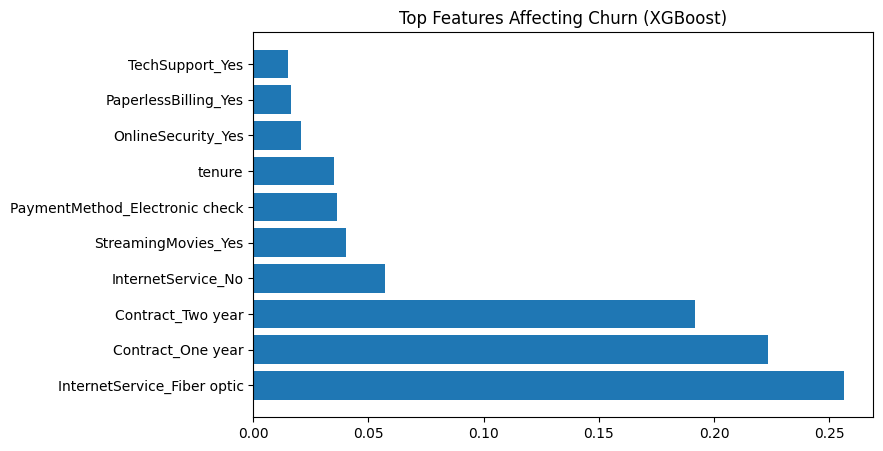

In [28]:
import matplotlib.pyplot as plt

top = importance_xgb.head(10)

plt.figure(figsize=(8,5))
plt.barh(top["Feature"], top["Importance"])
plt.title("Top Features Affecting Churn (XGBoost)")
plt.show()